# Regression and LASSO Analysis
This notebook loads the dataset and runs OLS and LASSO models.

In [2]:
from pathlib import Path

import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

In [3]:
df = pd.read_csv(DATA_DIR / "dmv_rent_income_dataset.csv")
df.head()

,zip,year,median_income,median_rent,rent_to_income,pct_renter,poverty_rate,pct_bachelors_plus,pct_white,pct_black,pct_asian,pct_hispanic,pct_male,pct_female,pct_under18,pct_elderly
0,20001,2018,109318.0,2021,0.221848,0.644516,0.155507,0.501349,0.397444,0.408126,0.069441,0.089413,0.483731,0.516269,0.093630,0.079009
1,20002,2018,84892.0,1558,0.220233,0.606318,0.145962,0.447800,0.408167,0.468788,0.030896,0.063225,0.479405,0.520595,0.166022,0.087973
2,20003,2018,126323.0,2037,0.193504,0.534648,0.101011,0.600711,0.599205,0.274693,0.027392,0.060007,0.518534,0.481466,0.144299,0.095825
3,20004,2018,147522.0,2597,0.211250,0.602317,0.054684,0.822278,0.664304,0.034430,0.120506,0.124557,0.521519,0.478481,0.071899,0.105316
4,20005,2018,94611.0,1885,0.239084,0.774978,0.101276,0.635229,0.542883,0.152019,0.085388,0.188020,0.498336,0.501664,0.079337,0.085464


In [17]:
y = df["rent_to_income"]

X = df[[
    "pct_renter",
    "poverty_rate",
    "pct_bachelors_plus",
    "pct_white",
    "pct_black",
    "pct_asian",
    "pct_hispanic",
    "pct_under18",
    "pct_elderly"
]]

data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data["rent_to_income"]

In [ ]:
# Check for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_df)

             Variable          VIF
0               const  6103.699725
1          pct_renter     2.747143
2        poverty_rate     2.557964
3  pct_bachelors_plus     3.353274
4           pct_white   331.976715
5           pct_black   341.069089
6           pct_asian    52.441322
7        pct_hispanic    77.815328
8         pct_under18     2.220371
9         pct_elderly     1.356488


In [24]:
# Drop one of the highly collinear variables (i.e."pct_white") and check VIF again
X_new = X.drop(columns = ["pct_black"])
vif_df_new = pd.DataFrame()
X_vif_new = sm.add_constant(X_new)
vif_df_new["Variable"] = X_vif_new.columns
vif_df_new["VIF"] = [variance_inflation_factor(X_vif_new.values, i) for i in range(X_vif_new.shape[1])]
print(vif_df_new)

             Variable         VIF
0               const  125.439245
1          pct_renter    2.746924
2        poverty_rate    2.556872
3  pct_bachelors_plus    3.336191
4           pct_white    1.852745
5           pct_asian    1.396156
6        pct_hispanic    1.372981
7         pct_under18    2.158479
8         pct_elderly    1.325334


In [25]:
# Fit OLS regression model
X_ols = sm.add_constant(X_new)
ols_model = sm.OLS(y, X_ols).fit()

print("===== OLS RESULTS =====")
print(ols_model.summary())

===== OLS RESULTS =====
                            OLS Regression Results                            
Dep. Variable:         rent_to_income   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     221.5
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          3.61e-200
Time:                        21:12:44   Log-Likelihood:                 1762.6
No. Observations:                 840   AIC:                            -3507.
Df Residuals:                     831   BIC:                            -3465.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const       

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=X_new.columns)

print("===== LASSO COEFFICIENTS =====")
print(lasso_coefs)

lasso_selected = lasso_coefs[lasso_coefs != 0]

print("===== SELECTED VARIABLES =====")
print(lasso_selected)

===== LASSO COEFFICIENTS =====
pct_renter            0.025265
poverty_rate          0.014395
pct_bachelors_plus   -0.017322
pct_white            -0.005046
pct_asian             0.008885
pct_hispanic         -0.003394
pct_under18          -0.005407
pct_elderly          -0.002197
dtype: float64
===== SELECTED VARIABLES =====
pct_renter            0.025265
poverty_rate          0.014395
pct_bachelors_plus   -0.017322
pct_white            -0.005046
pct_asian             0.008885
pct_hispanic         -0.003394
pct_under18          -0.005407
pct_elderly          -0.002197
dtype: float64


In [1]:
lasso_coefs.to_csv(DATA_DIR / "lasso_coefficients.csv", index=True)

NameError: name 'lasso_coefs' is not defined

## Visualization

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.linear_model import lasso_path

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

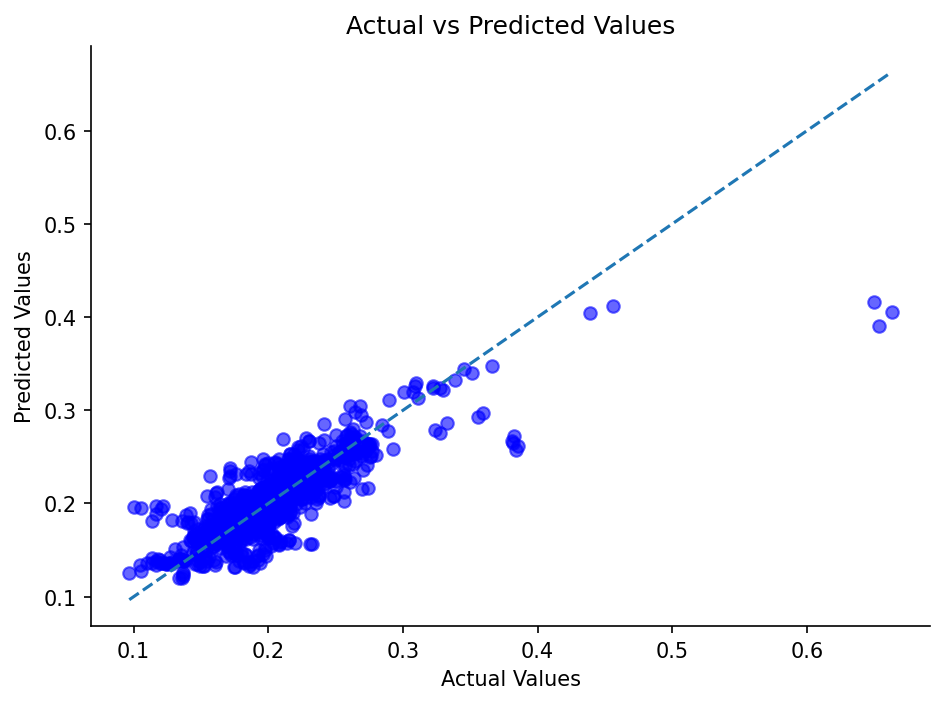

In [33]:
# Actual vs Predicted Plot
y_pred = ols_model.predict(X_ols)
plt.scatter(y,y_pred, color='blue', label='Actual', alpha=0.6)
plt.plot(
    [min(y), max(y)],
    [min(y), max(y)],
    linestyle='--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()

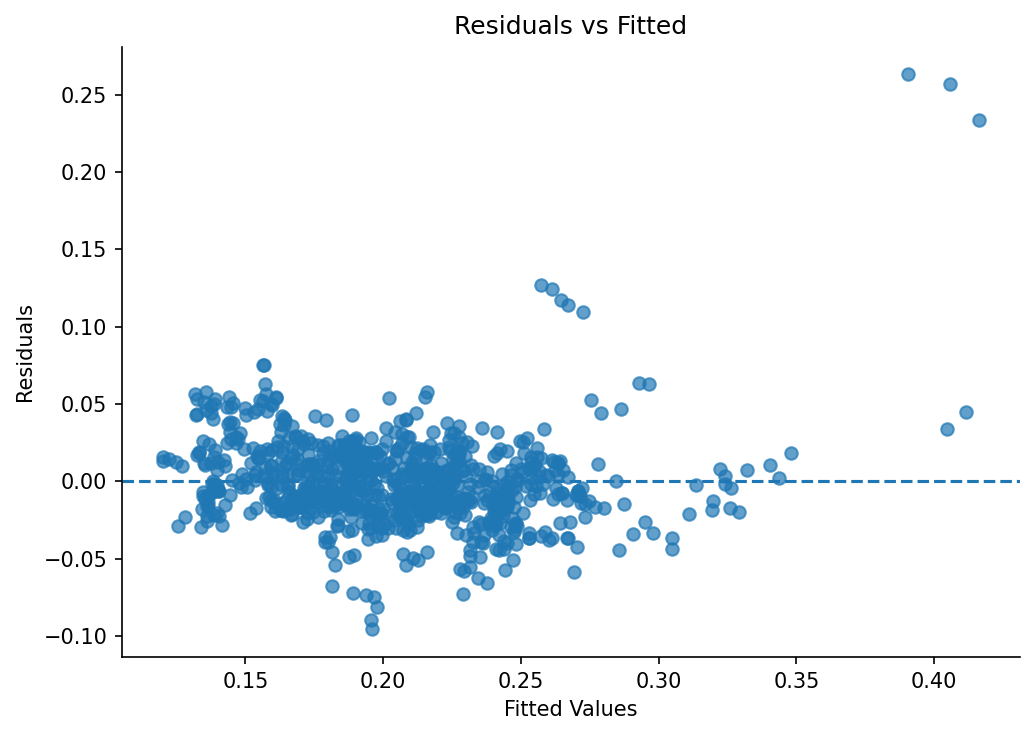

In [34]:
# Residuals vs Fitted Plot
residuals = y - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

## Lasso Regularization Path

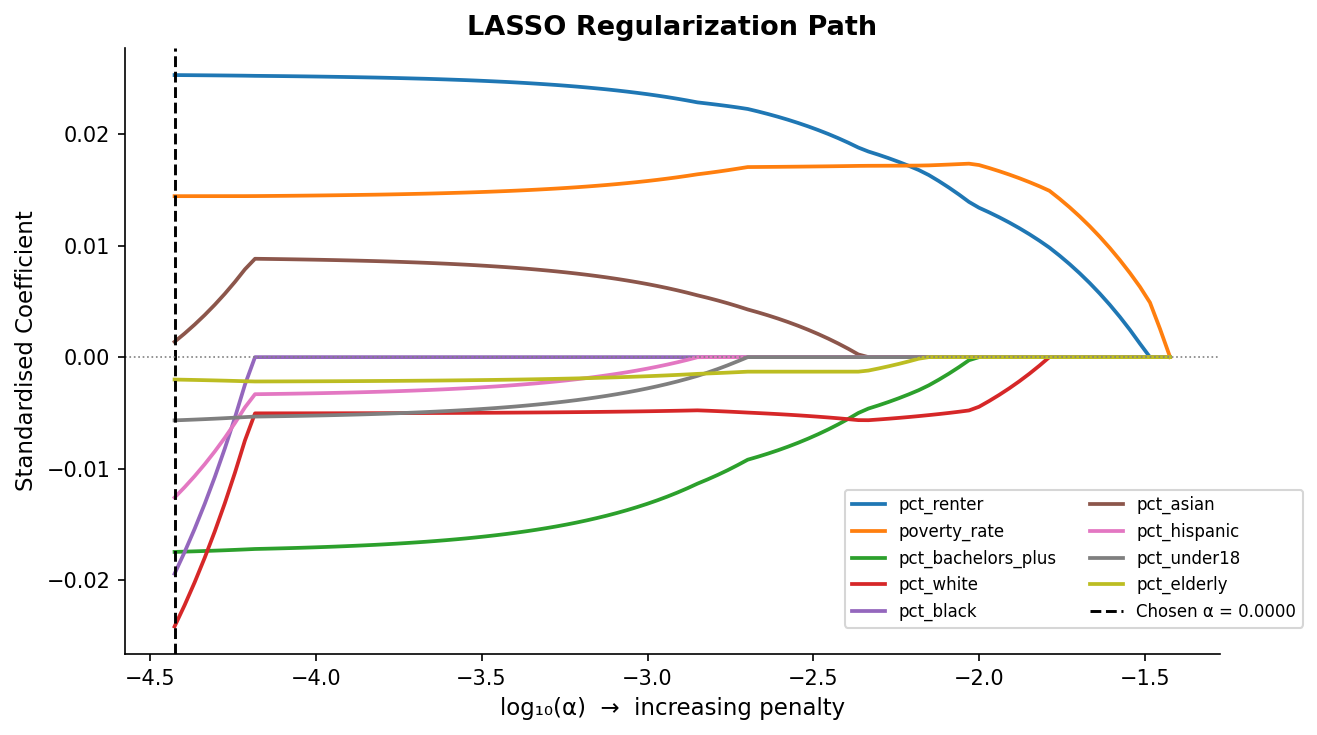

Saved → viz1_regularization_path.png


In [12]:
alphas_path, coefs_path, _ = lasso_path(X_scaled, y, max_iter=10000)

fig, ax = plt.subplots(figsize=(9, 5))

colors = plt.cm.tab10.colors
for i, col in enumerate(X.columns):
    ax.plot(np.log10(alphas_path), coefs_path[i], label=col,
            color=colors[i % len(colors)], linewidth=1.8)

ax.axvline(np.log10(lasso.alpha_), color='black', linestyle='--',
           linewidth=1.4, label=f'Chosen α = {lasso.alpha_:.4f}')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('log₁₀(α)  →  increasing penalty', fontsize=11)
ax.set_ylabel('Standardised Coefficient', fontsize=11)
ax.set_title('LASSO Regularization Path', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(0.65, 0.03), loc='lower left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('viz1_regularization_path.png', bbox_inches='tight')
plt.show()
print('Saved → viz1_regularization_path.png')

## Cross Validation

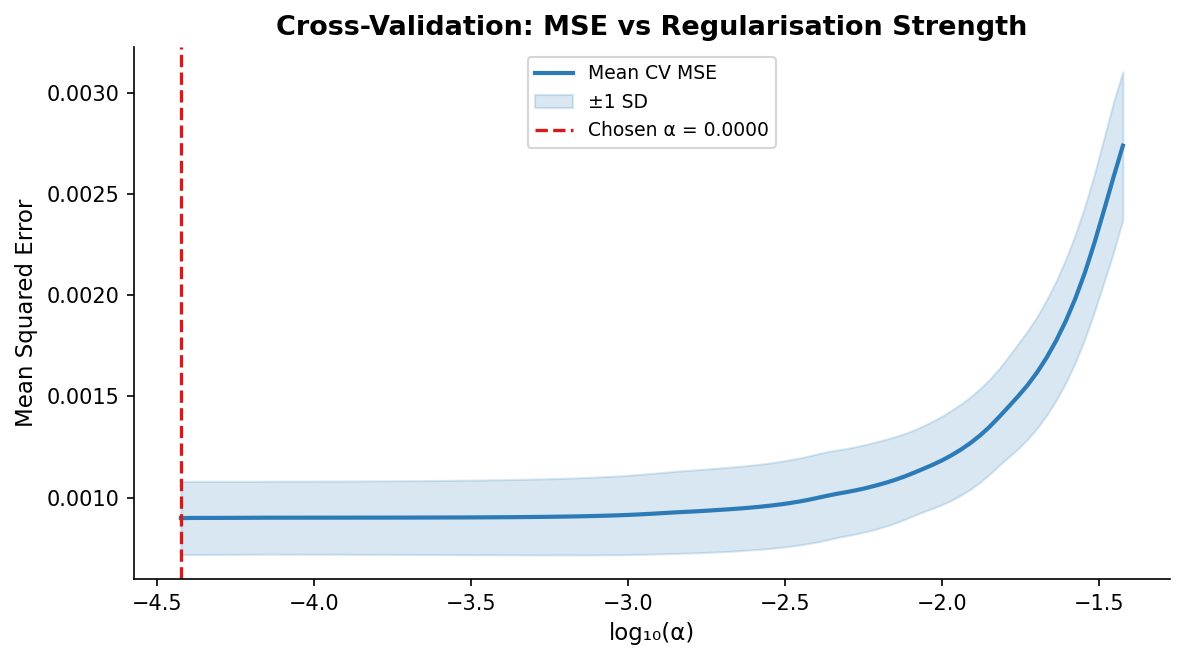

Saved → viz2_cv_alpha_selection.png


In [11]:
mean_mse   = lasso.mse_path_.mean(axis=1)
std_mse    = lasso.mse_path_.std(axis=1)
log_alphas = np.log10(lasso.alphas_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(log_alphas, mean_mse, color='#2c7bb6', linewidth=2, label='Mean CV MSE')
ax.fill_between(log_alphas, mean_mse - std_mse, mean_mse + std_mse,
                alpha=0.18, color='#2c7bb6', label='±1 SD')
ax.axvline(np.log10(lasso.alpha_), color='#d7191c', linestyle='--',
           linewidth=1.6, label=f'Chosen α = {lasso.alpha_:.4f}')
ax.set_xlabel('log₁₀(α)', fontsize=11)
ax.set_ylabel('Mean Squared Error', fontsize=11)
ax.set_title('Cross-Validation: MSE vs Regularisation Strength',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz2_cv_alpha_selection.png', bbox_inches='tight')
plt.show()
print('Saved → viz2_cv_alpha_selection.png')

## Lasso Coefficient Importance

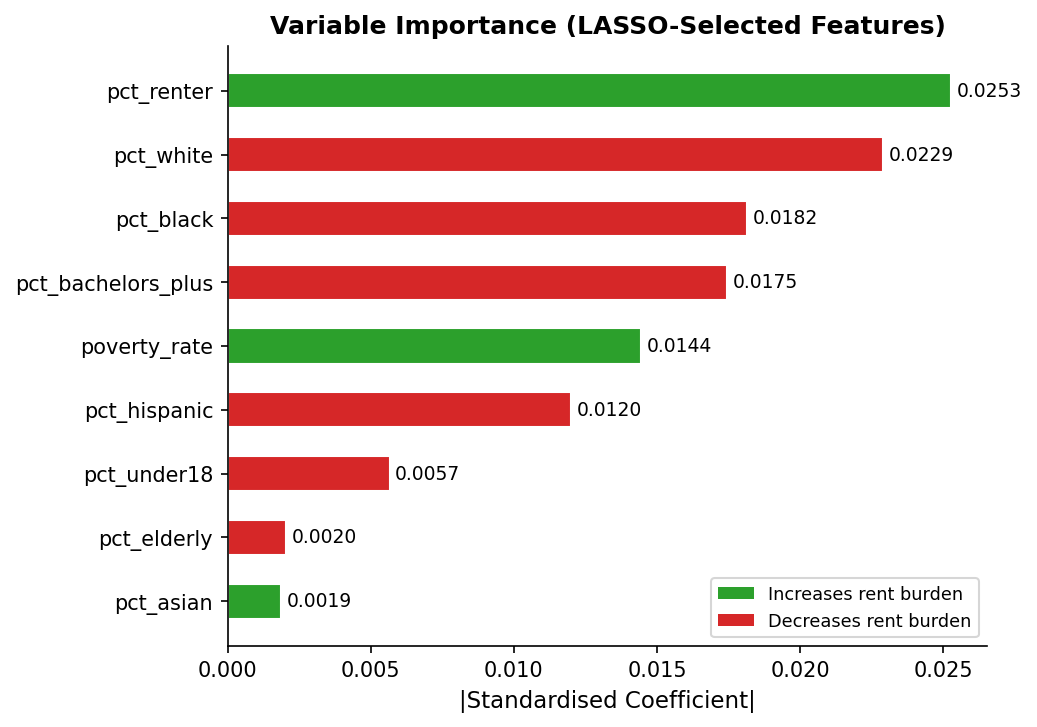

Saved → viz4_variable_importance.png


In [13]:
if len(lasso_selected) == 0:
    print('No variables were selected by LASSO.')
else:
    imp_df = lasso_selected.abs().reset_index()
    imp_df.columns = ['Variable', 'Abs_Coef']
    imp_df = imp_df.sort_values('Abs_Coef', ascending=True)

    dir_colors = [
        '#2ca02c' if lasso_selected[v] > 0 else '#d62728'
        for v in imp_df['Variable']
    ]

    fig, ax = plt.subplots(figsize=(7, max(3.5, 0.55 * len(imp_df))))
    bars = ax.barh(imp_df['Variable'], imp_df['Abs_Coef'],
                   color=dir_colors, edgecolor='white', height=0.55)

    for bar, val in zip(bars, imp_df['Abs_Coef']):
        ax.text(val + 0.0002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('|Standardised Coefficient|', fontsize=11)
    ax.set_title('Variable Importance (LASSO-Selected Features)',
                 fontsize=12, fontweight='bold')

    legend_elements = [
        Patch(facecolor='#2ca02c', label='Increases rent burden'),
        Patch(facecolor='#d62728', label='Decreases rent burden'),
    ]
    ax.legend(handles=legend_elements, fontsize=8.5)

    plt.tight_layout()
    plt.savefig('viz4_variable_importance.png', bbox_inches='tight')
    plt.show()
    print('Saved → viz4_variable_importance.png')

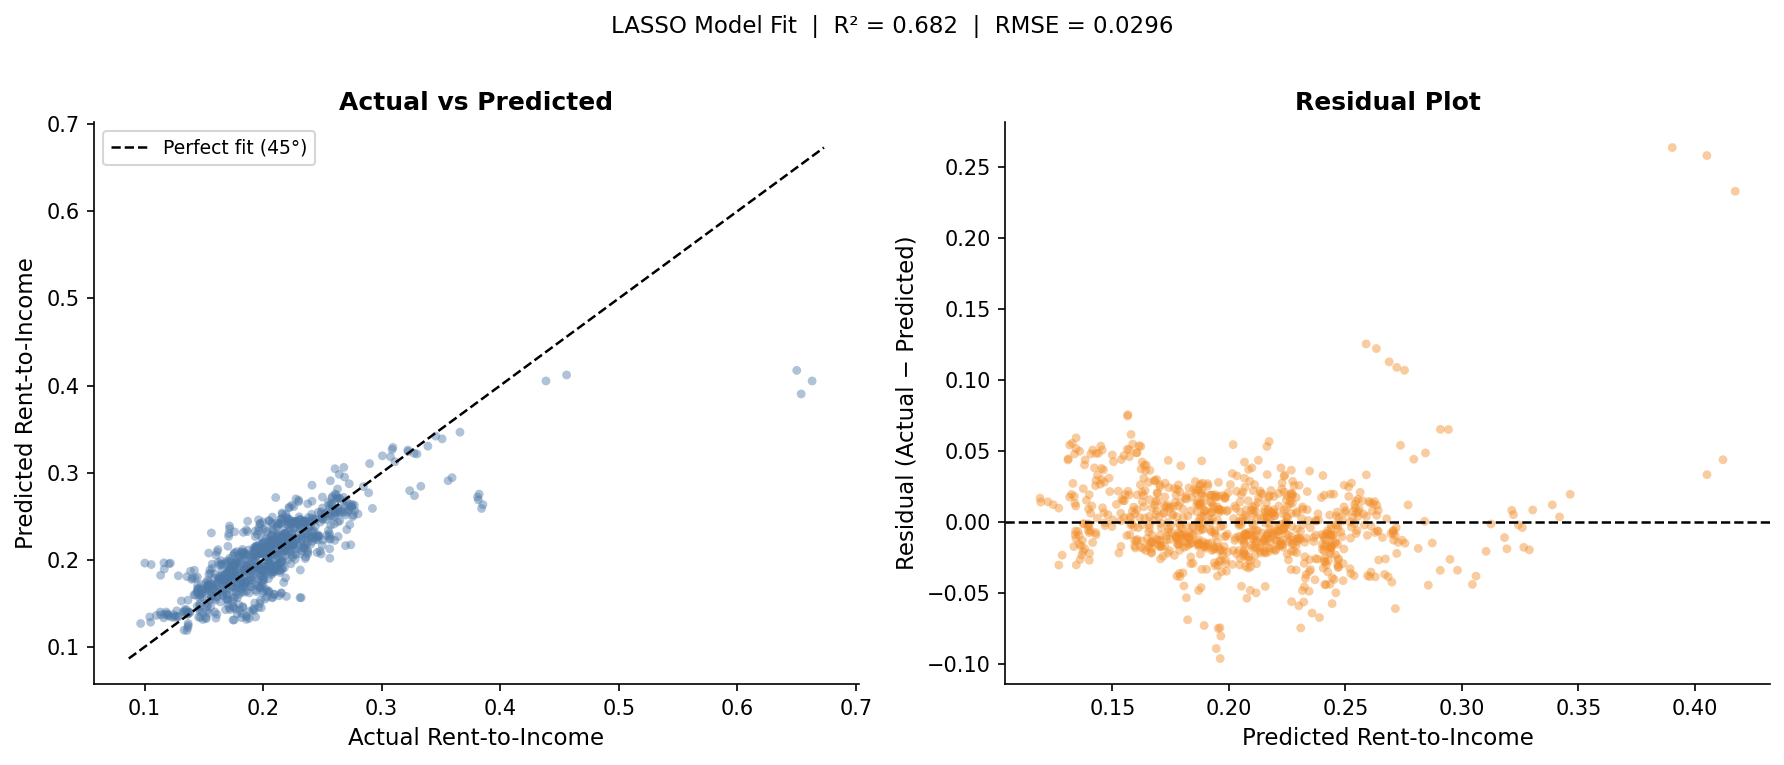

Saved → viz5_actual_vs_predicted.png  |  R² = 0.682  |  RMSE = 0.0296


In [14]:
y_pred    = lasso.predict(X_scaled)
residuals = y - y_pred
r2        = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)
rmse      = np.sqrt(np.mean(residuals**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Actual vs Predicted
ax = axes[0]
ax.scatter(y, y_pred, alpha=0.45, s=18, color='#4e79a7', edgecolors='none')
lims = [min(y.min(), y_pred.min()) - 0.01, max(y.max(), y_pred.max()) + 0.01]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit (45°)')
ax.set_xlabel('Actual Rent-to-Income', fontsize=11)
ax.set_ylabel('Predicted Rent-to-Income', fontsize=11)
ax.set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Right: Residuals
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.45, s=18, color='#f28e2b', edgecolors='none')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Predicted Rent-to-Income', fontsize=11)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=11)
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')

fig.suptitle(f'LASSO Model Fit  |  R² = {r2:.3f}  |  RMSE = {rmse:.4f}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('viz5_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print(f'Saved → viz5_actual_vs_predicted.png  |  R² = {r2:.3f}  |  RMSE = {rmse:.4f}')

## OLS Visualization